# Multiple Lr with more than 1 independent features. :

## Here we're using "datasets/economic_index.csv" where:
- We have 2 independent features and one dependent features with Linear relation .
- Thus, it's Multi-LR.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import statsmodels.api as sm


In [ ]:
df=pd.read_csv("../datasets/economic_index.csv")
df.head()


,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [ ]:

print(df.isnull().sum())
print("---------------------------------- ")

print(df.info())

Unnamed: 0           0
year                 0
month                0
interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64
---------------------------------- 
<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         24 non-null     int64  
 1   year               24 non-null     int64  
 2   month              24 non-null     int64  
 3   interest_rate      24 non-null     float64
 4   unemployment_rate  24 non-null     float64
 5   index_price        24 non-null     int64  
dtypes: float64(2), int64(4)
memory usage: 1.3 KB
None


In [ ]:
print(df.columns.tolist())

['Unnamed: 0', 'year', 'month', 'interest_rate', 'unemployment_rate', 'index_price']


In [ ]:
df.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


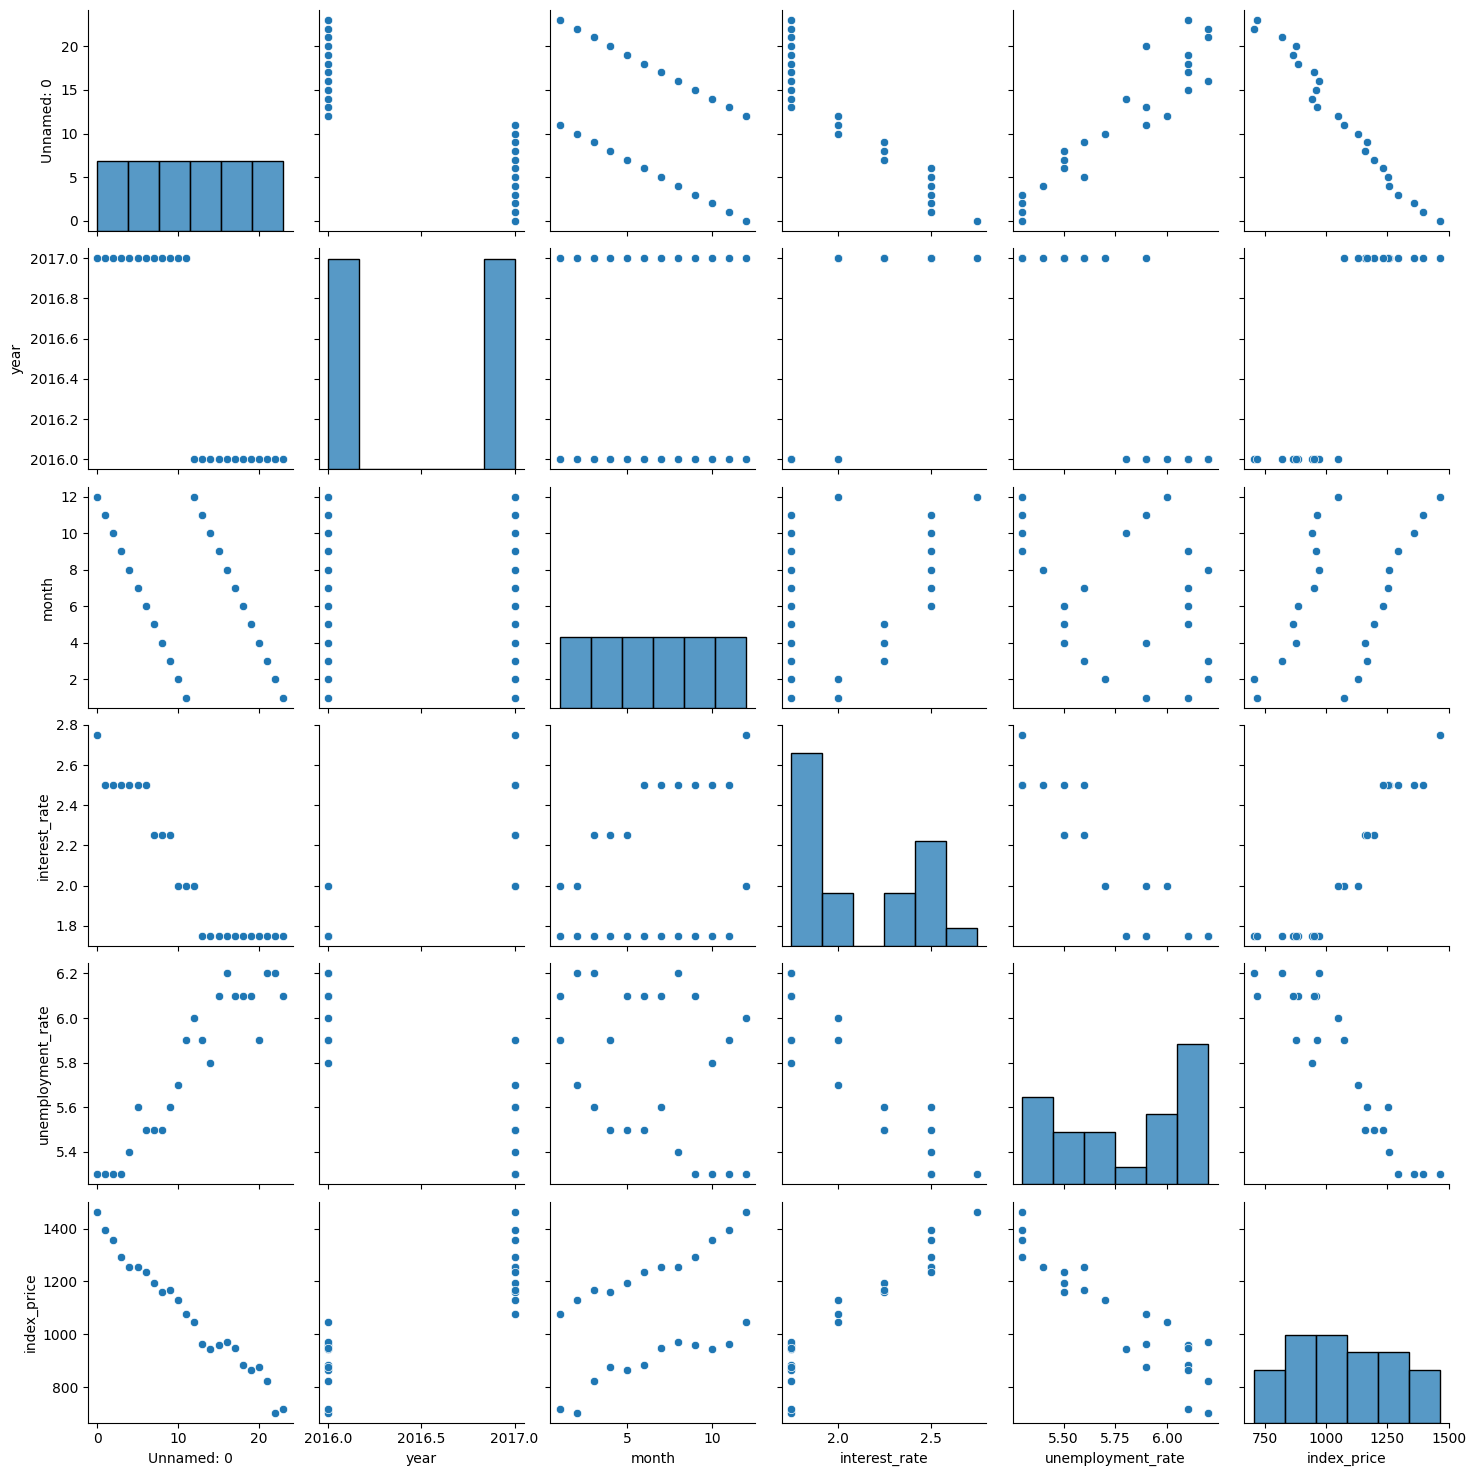

In [ ]:
sns.pairplot(df)

In [ ]:
df.corr()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
Unnamed: 0,1.000000,-8.667781e-01,-4.986939e-01,-0.934555,0.935300,-0.988246
year,-0.866778,1.000000e+00,7.884865e-14,0.882851,-0.877000,0.863232
month,-0.498694,7.884865e-14,1.000000e+00,0.339526,-0.351189,0.481287
interest_rate,-0.934555,8.828507e-01,3.395257e-01,1.000000,-0.925814,0.935793
unemployment_rate,0.935300,-8.769997e-01,-3.511891e-01,-0.925814,1.000000,-0.922338
index_price,-0.988246,8.632321e-01,4.812873e-01,0.935793,-0.922338,1.000000


Text(0, 0.5, 'berozgari')

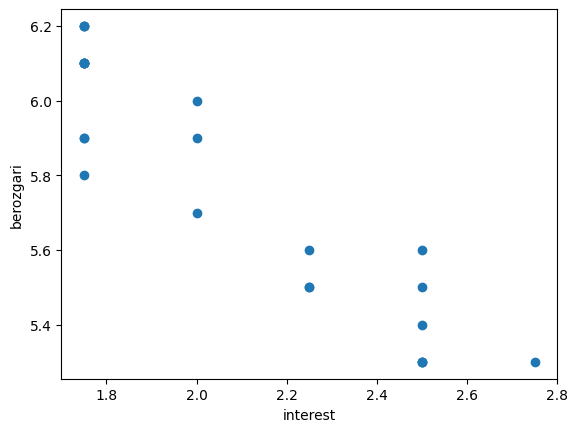

In [ ]:

print(plt.scatter(df["interest_rate"], df["unemployment_rate"]))
plt.xlabel("interest")
plt.ylabel("berozgari")


In [ ]:
# Printing the Dependent and independent vars.
X = df[['interest_rate', 'unemployment_rate']] # Note the double brackets for 2D array
y = df['index_price']


In [ ]:
# train test split :
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


In [ ]:
# Standardization :
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)


Axes(0.125,0.11;0.775x0.77)


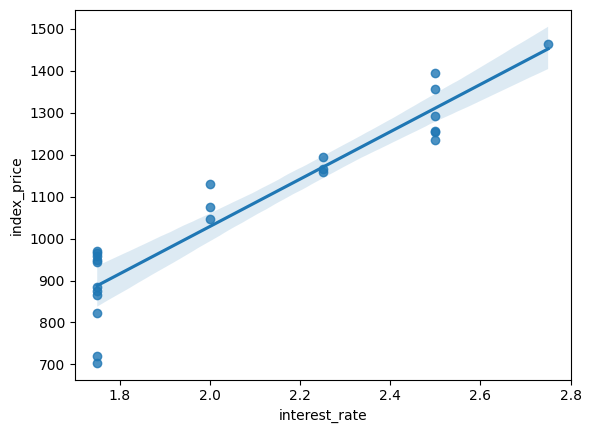

In [ ]:
import seaborn as sns

# Fix: Use keyword arguments
print(sns.regplot(x=df["interest_rate"], y=df["index_price"]))



Axes(0.125,0.11;0.775x0.77)


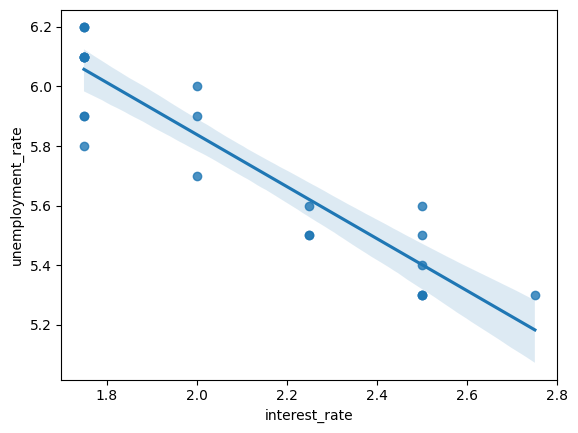

In [ ]:
print(sns.regplot(x=df["interest_rate"], y=df["unemployment_rate"]))

In [ ]:
from sklearn.linear_model import LinearRegression
regression =LinearRegression()
regression.fit(X_train_scaled, y_train)

print("Coeff:", regression.coef_)
print("Intercept:", regression.intercept_)

Coeff: [  88.27275507 -116.25716066]
Intercept: 1053.4444444444443


# Doing the cross validation of the data for hypertuning of model.

In [ ]:
#Cross validation 
from sklearn.model_selection import cross_val_score
validn_score= cross_val_score(regression, X_train_scaled, y_train, scoring="neg_mean_squared_error")


### Meaning of the syntax :
- Suppose we have the data of 100 vals of which we use 900 in trian and 100 in test.
- Now using the cross validatoin we can hypertune our model by again splitting the trainig data into training and validation.
- Suppose if we have cv=5 this means we split 900/5 =180
- So, we divide the data into chunks of 180 datasets.
- In the end we take the avg. of all the CVs
- And for good model working the -ve MSE should be close to 0. 

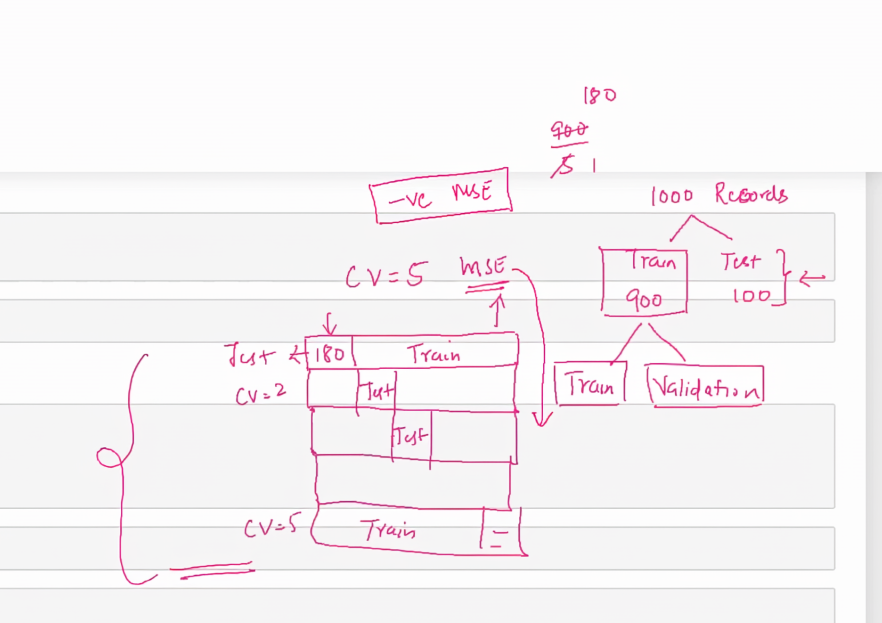

In [ ]:
print(validn_score)
print(" ")

print("mean :",np.mean(validn_score))

[-1861.74046551 -8715.8459466  -7707.52362191 -9169.13776461
  -791.32842311]
 
mean : -5649.115244350756


In [ ]:
y_pred_scaled= regression.predict(X_test_scaled)
print(y_pred_scaled)

[1204.22770398  821.65051903 1406.51300368  857.70889608  994.90992298
 1168.16932693]


In [ ]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_squared_error
mae=mean_absolute_error(y_test, y_pred_scaled)
mse=mean_squared_error(y_test, y_pred_scaled)
rmse=np.sqrt(mse)
print("RMSE: ", rmse)
print("MAE: ", mae)
print("MSE: ", mse)

# R-sq score:
from sklearn.metrics import r2_score
r_sq=r2_score(y_test, y_pred_scaled)
print("R-sq. :", r_sq)

# Adj r-sq value:
adj_r_sq= 1-(1-r_sq)*(len(y_test)-1)/(len(y_test)- X_test.shape[1] -1)
print("Adj R-sq :", adj_r_sq)


RMSE:  76.11677139574805
MAE:  59.935781523235484
MSE:  5793.762887712569
R-sq. : 0.8278978091457145
Adj R-sq : 0.7131630152428576


# Perfromamce mmetrics Visaulization:

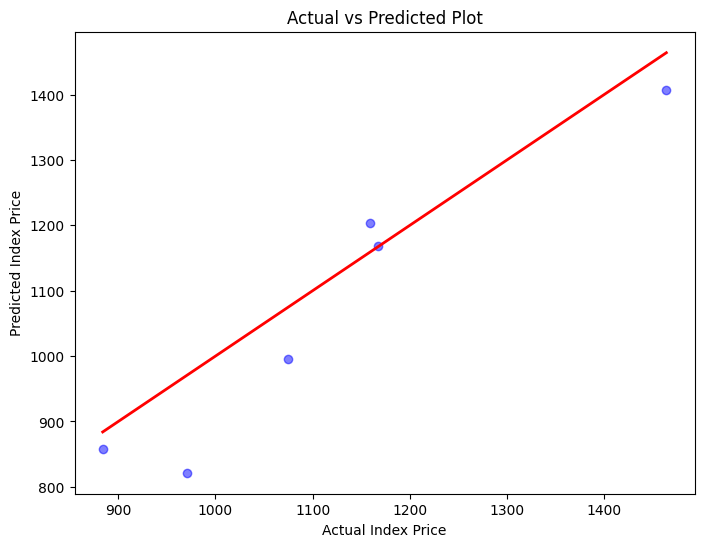

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_scaled, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.xlabel('Actual Index Price')
plt.ylabel('Predicted Index Price')
plt.title('Actual vs Predicted Plot')
plt.show()

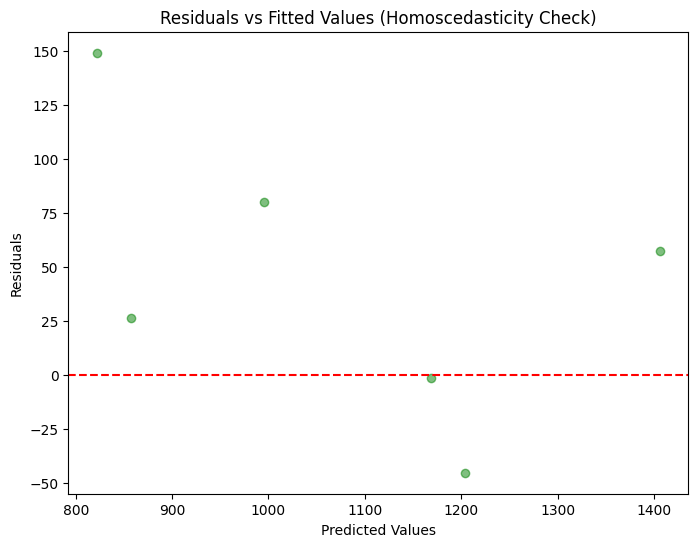

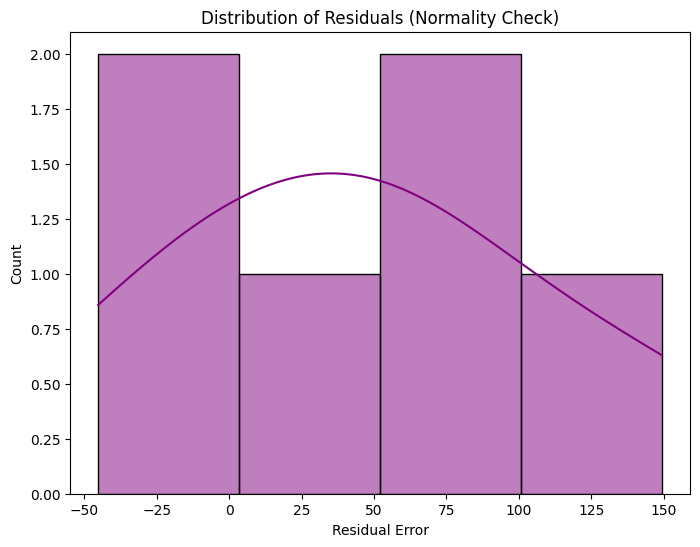

In [ ]:
# Residuals plot:
residuals = y_test - y_pred_scaled

plt.figure(figsize=(8, 6))
plt.scatter(y_pred_scaled, residuals, color='green', alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values (Homoscedasticity Check)')
plt.show()

import seaborn as sns

plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True, color='purple')
plt.title('Distribution of Residuals (Normality Check)')
plt.xlabel('Residual Error')
plt.show()

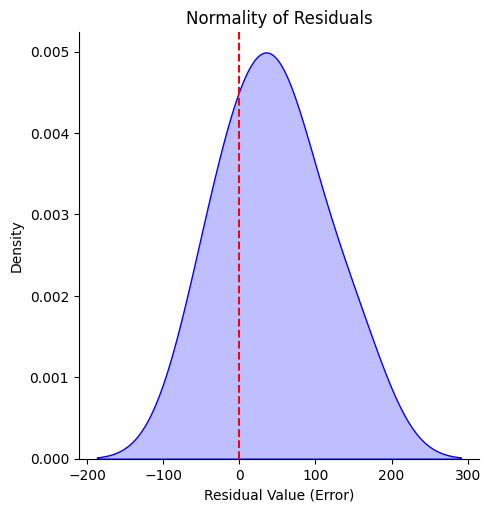

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculating residuals
residuals = y_test - y_pred_scaled

# Generating the KDE plot
sns.displot(residuals, kind='kde', fill=True, color='blue')

# Adding labels for clarity
plt.title('Normality of Residuals')
plt.xlabel('Residual Value (Error)')
plt.ylabel('Density')
plt.axvline(x=0, color='red', linestyle='--') # Reference line at 0
plt.show()

In [ ]:
coeff_df = pd.DataFrame(regression.coef_, X.columns, columns=['Coefficient'])
print(coeff_df)


                   Coefficient
interest_rate        88.272755
unemployment_rate  -116.257161


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif["feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif)

             feature        VIF
0      interest_rate  21.699835
1  unemployment_rate  21.699835


In [ ]:
from sklearn.metrics import r2_score, mean_squared_error

print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.8278978091457145
RMSE: 76.11677139574805


In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_poly, y, test_size=0.25, random_state=42)

model_poly = LinearRegression()
model_poly.fit(X_train_p, y_train_p)

y_pred_poly = model_poly.predict(X_test_p)

print("R2 (Polynomial):", r2_score(y_test_p, y_pred_poly))

R2 (Polynomial): 0.6455814024058448


# Testing the model :
- We're giving 10 values to the model and predicting thier o/p

In [10]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# 1. Load Data
df = pd.read_csv('../datasets/economic_index.csv')

# 2. Preprocessing
# Dropping non-numeric/index columns as identified before
df.drop(columns=['Unnamed: 0', 'year', 'month'], inplace=True, errors='ignore')

X = df[['interest_rate', 'unemployment_rate']]
y = df['index_price']

# 3. Standardization (Using the same scaler as training)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Model Training
model = LinearRegression()
model.fit(X_scaled, y)

# 5. Extract 10 Sample Points for Testing
X_samples = X.head(10)
y_samples_actual = y.head(10)

# Scale the samples before prediction
X_samples_scaled = scaler.transform(X_samples)
y_samples_pred = model.predict(X_samples_scaled)

# Creating a summary table
samples_results = pd.DataFrame({
    'Actual Price': y_samples_actual,
    'Predicted Price': y_samples_pred
})
print("Model Prediction Results on 10 Sample Data Points:")
print(samples_results)

Model Prediction Results on 10 Sample Data Points:
   Actual Price  Predicted Price
0          1464      1422.862389
1          1394      1336.477367
2          1357      1336.477367
3          1293      1336.477367
4          1256      1311.462710
5          1254      1261.433395
6          1234      1286.448053
7          1195      1200.063031
8          1159      1200.063031
9          1167      1175.048374


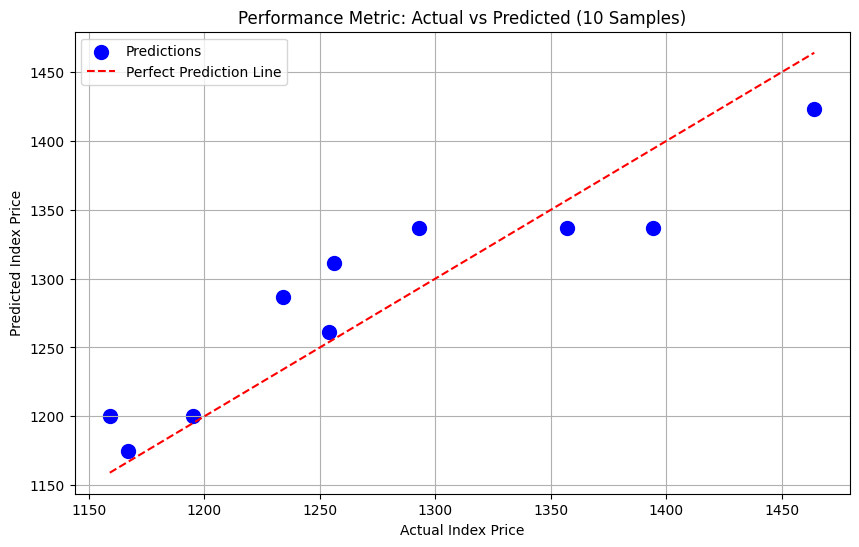

In [5]:
import matplotlib.pyplot as plt

# 6. Graphical Visualization
plt.figure(figsize=(10, 6))

# Plotting the samples
plt.scatter(y_samples_actual, y_samples_pred, color='blue', label='Predictions', s=100)

# 45-degree reference line (where Actual == Predicted)
plt.plot([y_samples_actual.min(), y_samples_actual.max()], 
         [y_samples_actual.min(), y_samples_actual.max()], 
         color='red', linestyle='--', label='Perfect Prediction Line')

plt.xlabel('Actual Index Price')
plt.ylabel('Predicted Index Price')
plt.title('Performance Metric: Actual vs Predicted (10 Samples)')
plt.legend()
plt.grid(True)
plt.show()

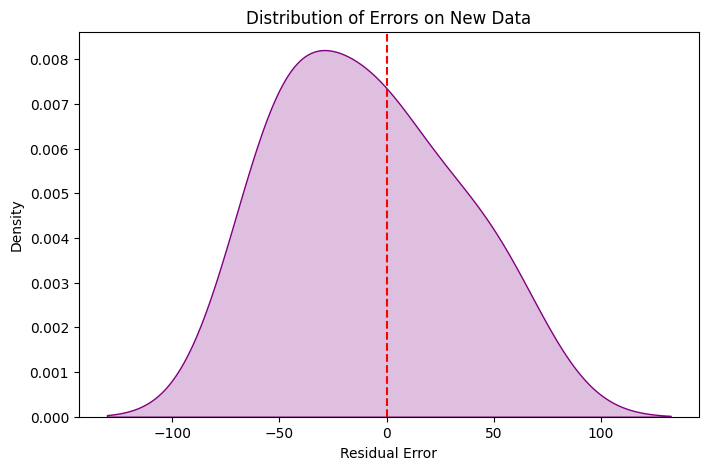

In [12]:
import seaborn as sns


test_residuals = y_samples_actual - y_samples_pred
plt.figure(figsize=(8, 5))
sns.kdeplot(test_residuals, fill=True, color="purple")
plt.axvline(x=0, color='red', linestyle='--')

plt.title('Distribution of Errors on New Data')
plt.xlabel('Residual Error')
plt.show()